# Lab 3: Projeto de Perfil

Módulos:
1. eulerblock.exe: airfoil.dat, settings.txt -> wall.dat, solution.vtk, derivatives.dat
2. gridgen2d.py: gera a malha
3. gridwarp.py: deforma a malha mas acho que não faz nada agora
4. euler_mod.py: chama eulerblock.exe
5. airfoil_mod.py (modificado para não usar pip): gera airfoil.dat dos parâmetros

Scripts em eulerblock_run_cases:
1. 01_airfoil_plotter/airfoil_plotter.py: analisar airfoil interativamente
2. 02_single_run/single_run.py: analisar airfoil não-interativamente
3. 03_optimize/optimize.py: otimizar airfoil para uma condição. Pode reinicializar com reload_opt = opt_results.pickle. Parâmetros de otimização: ftol, batentes Al_lower, Al_upper, Au_lower, Au_upper
4. 03_optimize/plot_history.py: plota progresso da otimização
5. paraview_layouts/paraview_state_windows.py: visualizar solution.vtk no paraview

Objetivo: otimizar perfil para o cruzeiro:
1. Mach = mach_cruise
2. altitude = altitude_cruise
3. Cl = Cl(y): curva elíptica de sustentação no cruzeiro, deformada pela corda variável da asa trapezoidal

Avião usado: Tomav final de PRJ-22 com tcr_w reduzido para 16%

Aerofólio inicial: NACA 1411

airfoil.dat -> XFOIL: utilize os seguintes comandos para ajustar a geometria:

• load airfoil.dat Carrega o aerofólio

• ppar Menu para ajuste dos painéis

• t Ajustar concentração de painéis no bordo de fuga

• 0.45 Fator de concentração

• n Ajustar número de painéis

• 200 Número de painéis

• <ENTER> Retornar ao menu anterior

• <ENTER> Retornar ao menu anterior

• oper Abrir menu de análise

• iter Definir número de iterações viscosas

• 100 Número máximo de iterações viscosas

• v Ativas análise viscosa

• Re_a ou Re_b Coloque o número de Reynolds desejado

• a Analisar ângulo de ataque

• 5 Angulo de ataque desejado (em graus)

## Instalar pacotes pip

In [1]:
from importlib.util import find_spec
if find_spec("numpy") is None or find_spec("pandas") is None or find_spec("matplotlib") is None \
    or find_spec("scipy") is None or find_spec("seaborn") is None:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "pandas", "matplotlib", "scipy", "seaborn"])

## Imports

In [2]:
import pickle
import time
import os
from pprint import pprint
from contextlib import contextmanager
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.optimize import root_scalar, minimize, Bounds

import airfoil_mod as am
from eulerblock import euler_mod as eb

from designTool.aerodynamics import aerodynamics
from designTool.auxiliary import atmosphere
from designTool.constants import gravity, ft2m
from designTool.standard_airplane import standard_airplane
from designTool.analyze import analyze

## Configurações

In [3]:
np.random.seed(1234)
pd.options.display.float_format = "{:,.2f}".format
sns.set_theme(style="whitegrid", context="notebook")

mpl.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.grid'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.rcParams['axes.xmargin'] = 0
plt.rcParams['axes.ymargin'] = 0

## Funções

In [4]:
def calcular_CL_voo(condicao, peso):
    atm = atmosphere(condicao["altitude"])
    rho = atm["density"]
    Mach = condicao["Mach"]
    V = Mach*atm["speed_of_sound"]
    CL = 2*peso / (rho*V**2*S_w)
    return CL


def aerodynamics_condicao_e_CL(airplane, condicao, CL):
    CD, CLmax, dragDict = aerodynamics(airplane, condicao["Mach"], condicao["altitude"], CL,
                                       n_engines_failed=condicao["n_engines_failed"],
                                       highlift_config=condicao["highlift_config"], lg_down=condicao["lg_down"],
                                       h_ground=condicao["h_ground"])
    return CD, CLmax, dragDict

def calcular_secao_asa(airplane, condicao, y, W_medio_cruise, log=False):
    # Geometria
    tct_w = airplane["inputs"]["tct_w"]
    tcr_w = airplane["inputs"]["tcr_w"]
    b_w = float(airplane["geometry"]["b_w"])
    cr_w = float(airplane["geometry"]["cr_w"])
    ct_w = float(airplane["geometry"]["ct_w"])
    tc_y = np.interp(y, [0, b_w/2], [tcr_w, tct_w])
    c_y = np.interp(y, [0, b_w/2], [cr_w, ct_w])

    # Aerodinâmica
    Mach = condicao["Mach"]
    altitude = condicao["altitude"]
    atm = atmosphere(altitude)
    rho = atm["density"]
    mu = atm["dyn_viscosity"]
    V_som = atm["speed_of_sound"]
    V = Mach*V_som
    Re = rho*V*c_y/mu

    # cl(y)
    # Distribuição elíptica de sustentação:
    # l(y) = l0 * sqrt(1 - (2y/b_w)^2)
    # Sustentação do perfil:
    # l(y) = q * c(y) * cl(y) (q = rho*V^2/2)
    # Sustentação total da asa: L = q*S_w*CL = W
    # 2 * integral(l(y), 0, b_w/2) = L
    # 2 * integral(l0 * sqrt(1 - (2y/b_w)^2), 0, b_w/2) = L
    # 2 * l0 * (pi*b_w/8) = L
    # l0 * pi * b_w / 4 = L
    # l0 = 4*L/(pi*b_w)
    q = rho*V**2/2
    L = W_medio_cruise
    l0 = 4*L/(np.pi*b_w)
    l_y = l0 * np.sqrt(1 - (2*y/b_w)**2)
    cl_y = l_y/(q*c_y)
    t_y = tc_y*c_y

    # Print
    if log:
        print(f"    y = {y:.2f} m")
        print(f"    tc_y = {tc_y:.1%}")
        print(f"    t_y = {(t_y*100):.2f} cm")
        print(f"    c_y = {c_y:.2f} m")
        print(f"    Re = {Re:.2e}")
        print(f"    cl_y = {cl_y:.4f}")

    return tc_y, c_y, Re, cl_y


def ajustar_tabela_latex(latex):
    latex = latex.replace(r"\toprule", "")
    latex = latex.replace(r"\midrule", r"\hline")
    latex = latex.replace(r"\bottomrule", "")
    latex = latex.replace(r"\hline \\", r"\hline")
    latex = latex.replace("%", r"\%")
    return latex

def rodar_xfoil_polar(pasta, Re, Mach, alpha_graus_min, alpha_graus_max, alpha_graus_step, NACA=None):
    xfoil_path =  os.path.join(os.path.abspath(os.getcwd()), "xfoil.exe")
    with working_directory(pasta):
        comandos = f"""{f"NACA {NACA}" if NACA is not None else "LOAD airfoil.dat"}
PPAR
T 0.45
N 200


OPER
ITER 100
VISC {Re}
MACH {Mach}
PACC
polar.txt

ASEQ {alpha_graus_min} {alpha_graus_max} {alpha_graus_step}
PACC

QUIT
"""
        if os.path.exists("polar.txt"):
            os.remove("polar.txt")
        result = subprocess.run(
            [xfoil_path],
            input=comandos,
            text=True,
            capture_output=True
        )
        returncode = result.returncode
        if returncode != 0:
            print("Erro ao rodar XFOIL:")
            pprint(result)
            raise Exception
        rows = []
        with open("polar.txt", "r") as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    values = [float(x) for x in line.strip().split()]
                except ValueError:
                    continue
                rows.append(values)
        polar = np.array(rows)
        polar = {
            "alpha": polar[:, 0],
            "CL": polar[:, 1],
            "CD": polar[:, 2],
            # "CDp": dados[:, 3],
            "CM": polar[:, 4],
            # "Top_Xtr": dados[:, 5],
            # "Bot_Xtr": dados[:, 6],
        }
        return polar

def rodar_euler(Al, Au, alpha, Mach, plot=False):
    # 02_single_run/single_run.py

    # Flow conditions
    gamma = 1.4 # ratio of specific heats of the fluid

    # Solver parameters
    order = 2 # 1 for 1st; 2 for 2nd
    iter = 20000 # Use 50000 for first order
    dt = 0.001 # Global time step (only used if use_local_dt==0) .Use 0.002 for first order and 0.001 for second order.
    CFL = 0.2 # Courant number used to compute local time steps (only used if use_local_dt==1)
    use_local_dt = 1 # Time stepping-strategy. 0 for global dt; 1 for local dt based on CFL.
    res_NK = 1e-4
    res_tol = 1e-6
    adj_funcs = []
    reinitialize = 0

    # Discretization (higher grid levels have higher number of elements)
    grid_level = 1.0

    # Reference mesh properties
    Nchord0 = 30 # Number of elements along the chord
    NJ0 = 48 # Number of elements along the normal direction
    s00 = 0.5e-2 # Reference mesh spacing

    Nchord = int((Nchord0*grid_level) + 1)
    NJ = int((NJ0*grid_level) + 1)
    s0 = NJ0/(NJ-1)*s00

    results = eb.run_cst(Al, Au, Nchord, alpha, Mach,
                        gamma, order,
                        iter, dt, CFL, use_local_dt, res_NK, res_tol,
                        reinitialize, adj_funcs, plot=plot, NJ=NJ, s0=s0)

    cl = results['CL']
    cd = results['CD']
    cm = results['CM']
    maxt = results['maxt']
    xmaxt = results['xmaxt']
    mint = results['mint']
    maxc = results['maxc']
    xmaxc = results['xmaxc']
    xx = results['distrib']['xx']
    Cp = results['distrib']['Cp']
    MachD = results['distrib']['Mach']
    grads = results['grads']

    print('Results')
    print('max thickness=',maxt)
    print('max thickness x/c=',xmaxt)
    print('max camber=',maxc)
    print('max camber x/c=',xmaxc)
    print('CL=',cl)
    print('CD=',cd)
    print('CM=',cm)
    # print('grads=',grads)

    # # Refine coordinates for xfoil export
    # x = (1-np.cos(np.linspace(0, 1, 81)*np.pi))/2
    # airfoil = am.cstfoil(Au, Al, x)
    # xf = airfoil['x_coord']
    # yf = airfoil['y_coord']
    # maxt = airfoil['max_thickness']
    # xmaxt = airfoil['x_max_thickness']
    # mint = airfoil['min_thickness']
    # maxc = airfoil['max_camber']
    # xmaxc = airfoil['x_max_camber']
    # am.export_airfoil(airfoil, title='AIRFOIL', filename='airfoil.dat')

    # # Example of how to plot Cp curve and airfoil coordinates
    # fig = plt.figure()
    # plt.subplot(311)
    # plt.plot(xx,Cp)
    # plt.ylabel('Cp')
    # plt.gca().invert_yaxis()
    # plt.subplot(312)
    # plt.plot(xx,MachD)
    # plt.ylabel('Mach')
    # plt.subplot(313)
    # plt.plot(xf,yf)
    # plt.axis('equal')
    # plt.ylabel('y/c')
    # plt.xlabel('x/c')
    # plt.tight_layout()
    # plt.show()

    return results

def exportar_airfoil(Al, Au, title='AIRFOIL', filename='airfoil.dat'):
    # Refine coordinates for xfoil export
    x = (1-np.cos(np.linspace(0, 1, 81)*np.pi))/2
    airfoil = am.cstfoil(Au, Al, x)
    am.export_airfoil(airfoil, title=title, filename=filename, close_te=False)

def encontrar_alpha_para_cl(pasta, Al, Au, Mach, cl, bracket):
    with working_directory(pasta):
        if os.path.exists("results.pickle"):
            with open("results.pickle", "rb") as f:
                results = pickle.load(f)
                alpha = results["alpha"]
                return alpha, results
            
        def rodar_euler_alpha(alpha):
            print(f"\n=== Testando alpha = {np.rad2deg(alpha):.3f}° ===\n")
            results = rodar_euler(Al, Au, alpha, Mach)
            return results["CL"]

        print(f"Encontrando alpha para cl = {cl:.4f}")
        sol = root_scalar(
            lambda alpha: rodar_euler_alpha(alpha) - cl,
            bracket=bracket,
            method='brentq',
            xtol=np.deg2rad(0.01)
        )
        if not sol.converged:
            print("Não foi possível encontrar alpha para cl = %.4f" % cl)
            pprint(sol)
            raise Exception

        alpha = sol.root
        print(f"\n=== alpha encontrado com {sol.function_calls} chamadas ao Euler Solver: {np.rad2deg(alpha):.2f}° ===\n")
        results = rodar_euler(Al, Au, alpha, Mach)
        print(f"Resultados calculados para alpha = {np.rad2deg(alpha):.2f}°.")
        with open("results.pickle", "wb") as f:
            pickle.dump(results, f)
        return alpha, results

def otimizar_airfoil(pasta, Mach, CLref, tref):
    with working_directory(pasta):
        if os.path.exists("results.pickle"):
            with open("results.pickle", "rb") as f:
                opt_result, results, elapsed, Al, Au, alpha = pickle.load(f)
                return opt_result, results, elapsed, Al, Au, alpha
        
        #===============================================
        # INPUTS

        # Minimum thickness allowed
        tlower = 0

        # Euler solver parameters
        order = 2 # 1 for 1st; 2 for 2nd
        iter = 20000 # max number of iterations (Use 50000 for first order)
        dt = 0.001 # Global time step (only used if use_local_dt==0). Use 0.002 for first order and 0.001 for second order. Reduce if you are getting NaNs or unstable solutions
        CFL = 0.2 # Courant number used to compute local time steps (only used if use_local_dt==1). Reduce if you are getting NaNs or unstable solutions
        use_local_dt = 1 # Time stepping-strategy. 0 for global dt; 1 for local dt based on CFL.
        res_NK = 1e-5 # Tolerance to switch from Runge-Kutta to Newton-Krylov solver. This value should be greater than res_tol.
        res_tol = 1e-8 # Tolerance on residual MSE to stop iterations. I do not recommend using values greater than 1e-6 (e.g. 1e-5), otherwise the numerical noise will break finite-difference estimations

        # Guess for initial angle of attack (this will be changed during the optimization)
        #alpha = 2.06*np.pi/180.0 # CL=0.5 for first order
        alpha = 1.405*np.pi/180.0 # CL=0.5 for second order

        # Airfoil discretization
        Nchord = 31
        cref = 1.0 # reference chord

        # Reference airfoil CST variables - NACA 1411
        Al = [-0.1489439, -0.10330027, -0.10305128, -0.10514982]
        Au = [ 0.16146332,  0.18349204,  0.14126241,  0.18194397]

        # Bounds for design variables
        # Al_lower = [-1.00, -1.00, -1.00, -1.00]
        # Al_upper = [-0.05, -0.05, -0.05, -0.05]
        # Au_lower = [ 0.05,  0.05,  0.05,  0.05]
        # Au_upper = [ 1.00,  1.00,  1.00,  1.00]
        Al_lower = [-1]*4
        Al_upper = [0.2]*4
        Au_lower = [-0.2]*4
        Au_upper = [1]*4
        # Number of airfoil CST parameters (design variables of the problem)
        Nvar = len(Al) # This value is used for the upper and lower skin separately (the total number of DVs is 2*Nvar)

        # Angle of attack bounds during optimizations
        alpha_min = -1*np.pi/180
        alpha_max =  6*np.pi/180

        # Select if we should use reinitialization for the first CFD analysis.
        # reinitialize = [0] does not use reinitialization for the first CFD analysis.
        # reinitialize = [1] uses reinitialization for the first CFD analysis.
        # We set it as a list so it remains accessible within the the check_point function.
        reinitialize = [0]

        # Option to reuse results from previous optimization.
        # This may be very useful to continue a previous optimization that was interrupted.
        # Make a copy of the opt_result.pickle file from a previous optimization, then add its name
        # to the variable below.
        # Use None to avoid this reinitialization.
        #reload_opt = None
        #reload_opt = 'opt_results_copy.pickle'
        if os.path.exists('opt_results.pickle'):
            reload_opt = 'opt_results.pickle'
        else:
            reload_opt = None

        #===============================================
        # EXECUTION

        # Initial airfoil design variables
        # The structure of the DV array is:
        # xx = [lower skin CST coefficients (Al); upper skin CST coefficients (Au); alpha]
        xx0 = np.hstack([Al, Au, alpha])

        # Initialize optimization history
        if reload_opt is None:
            xxhist = []
            CDhist = []
            CLhist = []
            maxthist = []
            minthist = []
            gradshist = []
        else:
            with open(reload_opt,'rb') as fid:
                hist_dict = pickle.load(fid)
                xxhist = hist_dict['xxhist']
                CDhist = hist_dict['CDhist']
                CLhist = hist_dict['CLhist']
                maxthist = hist_dict['maxthist']
                minthist = hist_dict['minthist']
                gradshist = hist_dict['gradshist']

        # Define function to check if the desired point was already executed
        def check_point(xx, tol=1e-11, force_run=False):
            # Loop over the history to find previous design point within tolerance
            ii_closest = -1
            for ii,xx_curr in enumerate(xxhist):
                delta = np.sqrt(np.sum((xx_curr - xx)**2))
                if delta < tol:
                    print('Found previous solution')
                    print('ii:',ii)
                    print('delta:',delta)
                    ii_closest = ii
                    break

            # Get design variables
            Al = xx[:Nvar]
            Au = xx[Nvar:2*Nvar]
            alpha = xx[-1]
            
            print('Evaluating the following point')
            print('Al:',Al)
            print('Au:',Au)
            print('alpha [deg]:',alpha*180/np.pi)

            # Choose whether to run new case or use history
            if (ii_closest == -1) or force_run: # i_closest keeps the default value if no match is found
                # Call Euler solver with adjoint for each function
                results = eb.run_cst(Al, Au, Nchord, alpha, Mach,
                                    gamma=1.4, order=order,
                                    iter=iter, dt=dt, CFL=CFL, use_local_dt=use_local_dt, res_NK=res_NK,
                                    res_tol=res_tol, reinitialize=reinitialize[0], plot=False,
                                    adj_funcs=['cl_jlow','cd_jlow'])
                CL = results['CL']
                CD = results['CD']
                maxt = results['maxt']
                mint = results['mint']
                grads1 = results['grads']

                # Gather gradients w.r.t. xx
                grads = {}
                grads['CL'] = np.hstack([grads1['cl_jlow']['dAl'],
                                        grads1['cl_jlow']['dAu'],
                                        [grads1['cl_jlow']['alpha']]])

                grads['CD'] = np.hstack([grads1['cd_jlow']['dAl'],
                                        grads1['cd_jlow']['dAu'],
                                        [grads1['cd_jlow']['alpha']]])

                grads['maxt'] = np.hstack([grads1['maxt']['dAl'],
                                        grads1['maxt']['dAu'],
                                        [0.0]])
                grads['mint'] = np.hstack([grads1['mint']['dAl'],
                                        grads1['mint']['dAu'],
                                        [0.0]])

                xxhist.append(xx.copy())
                CDhist.append(CD)
                CLhist.append(CL)
                maxthist.append(maxt)
                minthist.append(mint)
                gradshist.append(grads)
                with open('opt_results.pickle','wb') as fid:
                    pickle.dump({'xxhist':xxhist,
                                'CDhist':CDhist,
                                'CLhist':CLhist,
                                'maxthist':maxthist,
                                'minthist':minthist,
                                'mach':Mach,
                                'gradshist':gradshist,
                                'Al':Al,
                                'Au':Au}, fid)
            else:
                # Gather values from previous solution
                CL = CLhist[ii_closest]
                CD = CDhist[ii_closest]
                maxt = maxthist[ii_closest]
                mint = minthist[ii_closest]
                grads = gradshist[ii_closest]

            # Print and store history
            print('evaluation:',len(CDhist))
            print('CL:',CL)
            print('CD:',CD)
            print('maxt:',maxt)
            print('mint:',mint)
            print('Al:',Al)
            print('Au:',Au)
            print('alpha [deg]:',alpha*180/np.pi)
            print('grads:',grads)
            print('')

            # Check if we need to avoid solution reinitialization if NaNs show up
            if np.isnan(CL) or np.isnan(CD):
                reinitialize[0] = 0
            else:
                reinitialize[0] = 1

            # Return design functions
            return CL, CD, maxt, mint, grads

        # Define objective function
        def objfun(xx):
            CL, CD, maxt, mint, grads = check_point(xx)
            return CD

        def objfungrad(xx):
            CL, CD, maxt, mint, grads = check_point(xx)
            return grads['CD']

        # Define constraints
        def ineqconfun(xx):
            CL, CD, maxt, mint, grads = check_point(xx)
            g1 = (maxt - tref)
            g2 = -(tlower - mint)
            return g1, g2

        def ineqconfungrad(xx):
            CL, CD, maxt, mint, grads = check_point(xx)
            return grads['maxt'], grads['mint']

        # Define constraints
        def eqconfun(xx):
            CL, CD, maxt, mint, grads = check_point(xx)
            h1 = (CL - CLref)
            return h1

        def eqconfungrad(xx):
            CL, CD, maxt, mint, grads = check_point(xx)
            return grads['CL']

        # Run initial case
        objfun(xx0)
        reinitialize[0] = 1

        # Create list of constraints
        con1 = {'type': 'ineq',
                'fun': ineqconfun,
                'jac': ineqconfungrad}
        con2 = {'type': 'eq',
                'fun': eqconfun,
                'jac': eqconfungrad}
        cons = [con1, con2]

        # Set DV bounds
        #lb = [-Amax]*Nvar + [Amin]*Nvar + [alpha_min]
        #ub = [-Amin]*Nvar + [Amax]*Nvar + [alpha_max]
        lb = Al_lower + Au_lower + [alpha_min]
        ub = Al_upper + Au_upper + [alpha_max]
        bounds = Bounds(lb, ub, keep_feasible=True)

        # Set optimizer options.
        # Adjusted eps (finite difference size) according to expected DV bounds.
        options={'maxiter': 100, 'ftol': 1e-05, 'iprint': 1, 'disp': True}#, 'finite_diff_rel_step': None}

        # Run optimizer
        start_time = time.time()
        opt_result = minimize(objfun, x0=xx0, jac=objfungrad,
                        constraints=cons, bounds=bounds,
                        method='slsqp',
                        options=options)
        end_time = time.time()
        elapsed = end_time - start_time
        # Print results
        print('')
        print('=========================================')
        print('OPTIMIZATION RESULTS')
        print(opt_result)
        print('Optimization time: %d seconds'%elapsed)
        print('=========================================')
        print('')
        xopt = opt_result.x
        Al = xopt[:Nvar]
        Au = xopt[Nvar:2*Nvar]
        alpha = xopt[-1]
        
        # Run optimum point to make sure it is the last item
        # of the history file
        CL, CD, maxt, mint, grads = check_point(xopt, force_run=True)
        results = rodar_euler(Al, Au, alpha, Mach)
        
        print('')
        print('=========================================')
        print('OPTIMUM POINT')
        print('CL:',CL)
        print('CD:',CD)
        print('maxt:',maxt)
        print('xopt:',xopt)
        print('=========================================')
        print('')

        with open('results.pickle','wb') as f:
            pickle.dump(([opt_result, results, elapsed, Al, Au, alpha]), f)
        return opt_result, results, elapsed, Al, Au, alpha


def plot_history(pasta):
    with working_directory(pasta):
        with open('opt_results.pickle','rb') as f:
            hist_dict = pickle.load(f)

        xx_hist = np.asarray(hist_dict['xxhist'])
        CD_hist = np.asarray(hist_dict['CDhist'])
        CL_hist = np.asarray(hist_dict['CLhist'])
        maxt_hist = np.asarray(hist_dict['maxthist'])
        mint_hist = np.asarray(hist_dict['minthist'])
        mach_hist = np.asarray(hist_dict['mach'])

        plt.figure(figsize=(6, 12))
        plt.subplot(411)
        sns.lineplot(data=xx_hist, dashes=False)
        plt.legend(plt.gca().lines[:9], ["Al1", "Al2", "Al3", "Al4", "Au1", "Au2", "Au3", "Au4", "alpha"], loc="upper right")
        plt.ylabel(r'x')
        plt.subplot(412)
        sns.lineplot(data=CD_hist)
        plt.ylabel(r'$c_d$')
        plt.subplot(413)
        sns.lineplot(data=CL_hist)
        plt.ylabel(r'$c_l$')
        plt.subplot(414)
        sns.lineplot(data=maxt_hist, label="maxt")
        sns.lineplot(data=mint_hist, label="mint")
        plt.ylabel(r'$t/c$')
        plt.xlabel('Function evaluations')
        plt.tight_layout()
        plt.xlim(0, len(CD_hist))

        # The number of airfoil coefficients is half of xx
        # after discounting the alpha
        Nvar = (len(xx_hist[0,:])-1)//2

        Al = xx_hist[-1,:Nvar]
        Au = xx_hist[-1,Nvar:2*Nvar]
        alpha = xx_hist[-1,-1]
        xa = (1-np.cos(np.linspace(0, 1, 81)*np.pi))/2

        airfoil = am.cstfoil(Au, Al, xa)
        x = airfoil['x_coord']
        y = airfoil['y_coord']
        maxt = airfoil['max_thickness']
        xmaxt = airfoil['x_max_thickness']
        mint = airfoil['min_thickness']
        maxc = airfoil['max_camber']
        xmaxc = airfoil['x_max_camber']

        # Read the most recent wall.dat file stored in the folder
        cl,cd,cm,xxD,Cp,MachD = eb.postprocess(x,y,alpha,mach_hist,plot=False)

        print('Results for the last airfoil in history')
        print('max thickness=',maxt)
        print('max thickness x/c=',xmaxt)
        print('max camber=',maxc)
        print('max camber x/c=',xmaxc)
        print('CL=',cl)
        print('CD=',cd)
        print('CM=',cm)

        plt.show()

@contextmanager
def working_directory(path):
    old = os.getcwd()
    os.makedirs(path, exist_ok=True)
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(old)

## Atividades

### 1. Primeiramente precisamos determinar um ponto de projeto (altitude, Mach e peso) para otimizar o aerofólio. Uma vez que esse ponto for estabelecido, calcule o coeficiente de sustentação (CL) correspondente para a aeronave. Em seguida, tome a corda média aerodinâmica da asa como corda de referência (cref) e, para fins desse exercício, assuma que o coeficiente de sustentação dessa seção é igual ao CL da aeronave (clref = CL). Utilize a espessura média da aeronave da equipe para determinar o valor de espessura mínima para a otimização (t/c)ref. Utilize tais dados para preencher a Tab. 1. Mostre no relatório o procedimento de cálculo dos itens presentes na planilha.


#### Avião Tomav no cruzeiro

In [5]:
airplane_name = "Tomav"
airplane = standard_airplane(airplane_name)
airplane["inputs"]["tcr_w"] = 0.16
analyze(airplane)

W0 = float(airplane["thrust_matching"]["W0"])
b_w = float(airplane["geometry"]["b_w"])
S_w = airplane["inputs"]["S_w"]
clmax_w = airplane["inputs"]["clmax_w"]
Mach_cruise = airplane["inputs"]["Mach_cruise"]
altitude_cruise = airplane["inputs"]["altitude_cruise"]

CondicaoCruise = {
    "Mach": Mach_cruise,
    "altitude": altitude_cruise,
    "n_engines_failed": 0,
    "highlift_config": "clean",
    "lg_down": 0,
    "h_ground": 0,
}

print(f"Mach_cruise = {Mach_cruise:.2f}")
print(f"altitude_cruise = {altitude_cruise:.0f} m")

Mach_cruise = 0.85
altitude_cruise = 9876 m


In [6]:
pprint(airplane)

{'aerodynamics': {'AR_eff': 12.6,
                  'Swet_f': 929.3090576756209,
                  'dragDict': {'CD': 0.10110612036403044,
                               'CD0': 0.0522002625741497,
                               'CD0_exc': 0.0015660078772244909,
                               'CD0_f': 0.005114441192412262,
                               'CD0_flap': 0.028430307662060714,
                               'CD0_h': 0.001212493386582208,
                               'CD0_lg': 0.0,
                               'CD0_n': 0.001304133952973577,
                               'CD0_slat': 0.0001731900633678261,
                               'CD0_v': 0.0009858584985122864,
                               'CD0_w': 0.004667350394090193,
                               'CD0_wdm': 0.008746479546926127,
                               'CDind': 0.04890585778988074,
                               'CDwave': 0.0,
                               'CL': 1.2208392679106645,
                      

#### Peso médio no cruzeiro

In [7]:
# Equação de Breguet: R = (V/TSFC)*(L/D)*ln(Wi/Wf)
# => Wf = Wi * exp(-K*R), K = 1/((V/TSFC)*(L/D))
# W_medio = W(x=R/2)
# W_medio = Wi * exp(-K*R/2)
# W_medio = Wi * sqrt(exp(-K*R))
# W_medio = Wi * sqrt(Wf/Wi)
# W_medio = sqrt(Wi * Wf)
# => média geométrica

fases = ["start", "taxi", "takeoff", "climb", "cruise", "descent", "altcruise", "loiter", "landing"]
fracoes = [airplane["fuel_weight"]["Mf_hist"][fase] for fase in fases]
pesos = [0 for _ in range(len(fracoes) + 1)]
pesos[0] = W0
for i, f in enumerate(fracoes):
    pesos[i + 1] = pesos[i] * fracoes[i]
PesosFinais = {fase: peso for fase, peso in zip(fases, pesos[1:])}
PesosIniciais = {fase: peso for fase, peso in zip(fases, pesos[:-1])}
W_medio_cruise = (PesosIniciais["cruise"]*PesosFinais["cruise"])**0.5
print(f"W_medio_cruise = {(W_medio_cruise/gravity):.1f} kgf")

W_medio_cruise = 205928.1 kgf


#### Aerodinâmica média no cruzeiro

In [8]:
CL_medio_cruise = calcular_CL_voo(CondicaoCruise, W_medio_cruise)
CD_medio_cruise, CLmax_medio_cruise, dragDict_medio_cruise = aerodynamics_condicao_e_CL(airplane, CondicaoCruise, CL_medio_cruise)

atm = atmosphere(altitude_cruise)
rho = atm["density"]
V_som = atm["speed_of_sound"]

print(f"CL_medio_cruise = {CL_medio_cruise:.4f}")
print(f"CD_medio_cruise = {CD_medio_cruise:.4f}")
print(f"CLmax_medio_cruise = {CLmax_medio_cruise:.4f}")
print(f"Velocidade do som = {V_som:.2f} m/s")
print(f"Densidade do ar = {rho:.4f} kg/m³")

CL_medio_cruise = 0.4483
CD_medio_cruise = 0.0206
CLmax_medio_cruise = 1.3262
Velocidade do som = 300.04 m/s
Densidade do ar = 0.4199 kg/m³


#### Seção da asa

In [9]:
y = airplane["geometry"]["ym_w"]
tc, c, Re, cl = calcular_secao_asa(airplane, CondicaoCruise, y, W_medio_cruise, log=True)

    y = 11.24 m
    tc_y = 12.9%
    t_y = 84.75 cm
    c_y = 6.55 m
    Re = 4.76e+07
    cl_y = 0.4517


#### Decolagem

In [10]:
CondicaoDecolagem = {
        "Mach": 0.30,
        "altitude": 0,
        "n_engines_failed": 0,
        "highlift_config": "takeoff",
        "lg_down": 1,
        "h_ground": 10.668,
}
Mach_decolagem = CondicaoDecolagem["Mach"]
W_decolagem = PesosIniciais["takeoff"]

tc_decolagem, c_decolagem, Re_decolagem, cl_decolagem = calcular_secao_asa(airplane, CondicaoDecolagem, y, W_decolagem, log=True)

    y = 11.24 m
    tc_y = 12.9%
    t_y = 84.75 cm
    c_y = 6.55 m
    Re = 4.52e+07
    cl_y = 1.1756


#### Tabela 1

In [11]:
tabela1 = pd.DataFrame({
    "Parâmetro": [
        r"$h$",
        r"$M_\infty$",
        r"$W$",
        r"$S_{\mathrm{ref}}$",
        r"$b_w$",
        r"$\rho_\infty$",
        r"$a_\infty$",
        r"$y$",
        r"$c$",
        r"$c_l$",
        r"$Re$",
        r"$(t/c)$",
    ],
    "Valor": [
        f"{(altitude_cruise/ft2m):.0f} ft",
        f"{Mach_cruise:.2f}",
        f"{W_medio_cruise/gravity:.1f} kgf",
        rf"{S_w:.1f} $\mathrm{{m^2}}$",
        f"{b_w:.2f} m",
        rf"{rho:.3f} $\mathrm{{kg/m^3}}$",
        rf"{V_som:.1f} $\mathrm{{m/s}}$",
        f"{y:.2f} m",
        f"{c:.2f} m",
        f"{cl:.4f}",
        f"{Re:.2e}",
        f"{tc:.1%}",
    ],
    "Descrição": [
        "Altitude do ponto de projeto",
        "Mach do ponto de projeto",
        "Peso da aeronave no ponto de projeto",
        "Área de referência da aeronave",
        "Envergadura da asa",
        "Densidade do ar no ponto de projeto",
        r"Velocidade do som no ponto de projeto \\ \hline",
        "Posição da seção de referência",
        "Corda da seção de referência",
        "Coeficiente de sustentação da seção de referência",
        "Reynolds para a seção de referência",
        r"Espessura relativa da base da seção de referência",
    ]
})

print("Tabela 1:")
display(tabela1)

Tabela 1:


,Parâmetro,Valor,Descrição
0,$h$,32400 ft,Altitude do ponto de projeto
1,$M_\infty$,0.85,Mach do ponto de projeto
2,$W$,205928.1 kgf,Peso da aeronave no ponto de projeto
3,$S_{\mathrm{ref}}$,330.0 $\mathrm{m^2}$,Área de referência da aeronave
4,$b_w$,58.86 m,Envergadura da asa
5,$\rho_\infty$,0.420 $\mathrm{kg/m^3}$,Densidade do ar no ponto de projeto
6,$a_\infty$,300.0 $\mathrm{m/s}$,Velocidade do som no ponto de projeto \\ \hline
7,$y$,11.24 m,Posição da seção de referência
8,$c$,6.55 m,Corda da seção de referência
9,$c_l$,0.4517,Coeficiente de sustentação da seção de referência


#### LaTeX

In [12]:
latex1 = tabela1.to_latex(
    index=False,
    escape=False,
    na_rep="",
    caption="Dados para a seção de referência",
    label="tab:dados_secao",
    column_format=r"c|c|l"
)
latex1 = ajustar_tabela_latex(latex1)
print(latex1)

\begin{table}
\caption{Dados para a seção de referência}
\label{tab:dados_secao}
\begin{tabular}{c|c|l}

Parâmetro & Valor & Descrição \\
\hline
$h$ & 32400 ft & Altitude do ponto de projeto \\
$M_\infty$ & 0.85 & Mach do ponto de projeto \\
$W$ & 205928.1 kgf & Peso da aeronave no ponto de projeto \\
$S_{\mathrm{ref}}$ & 330.0 $\mathrm{m^2}$ & Área de referência da aeronave \\
$b_w$ & 58.86 m & Envergadura da asa \\
$\rho_\infty$ & 0.420 $\mathrm{kg/m^3}$ & Densidade do ar no ponto de projeto \\
$a_\infty$ & 300.0 $\mathrm{m/s}$ & Velocidade do som no ponto de projeto \\ \hline
$y$ & 11.24 m & Posição da seção de referência \\
$c$ & 6.55 m & Corda da seção de referência \\
$c_l$ & 0.4517 & Coeficiente de sustentação da seção de referência \\
$Re$ & 4.76e+07 & Reynolds para a seção de referência \\
$(t/c)$ & 12.9\% & Espessura relativa da base da seção de referência \\

\end{tabular}
\end{table}



### 2. Utilize os scripts da pasta 02_single_run para determinar qual o ângulo de ataque (variável alpha da linha 19) faz com que o perfil NACA 1411 atinja o cl de projeto. Lembre de atualizar também o número de Mach.

In [13]:
Al_NACA1411 = [-0.1489439, -0.10330027, -0.10305128, -0.10514982]
Au_NACA1411 = [0.16146332, 0.18349204, 0.14126241, 0.18194397]
bracket = (np.deg2rad(-0.5), np.deg2rad(1.5))

In [14]:
alpha_NACA, results_NACA = encontrar_alpha_para_cl("Lab3/NACA", Al_NACA1411, Au_NACA1411, Mach_cruise, cl, bracket)

Encontrando alpha para cl = 0.4517

=== Testando alpha = -0.500° ===

2D Grid generator
Written by:
Ney Rafael Secco
ney@ita.br
Jan 2016
Rev: Aug 2022

Growth ratio:  1.1404314716680044
Results
max thickness= 0.11012692902984474
max thickness x/c= 0.2966316784620998
max camber= 0.01009912176790169
max camber x/c= 0.3960441545911204
CL= 0.249007845
CD= 0.0466494498
CM= -0.157875579

=== Testando alpha = 1.500° ===

2D Grid generator
Written by:
Ney Rafael Secco
ney@ita.br
Jan 2016
Rev: Aug 2022

Growth ratio:  1.1404314716680044
Results
max thickness= 0.11012692902984474
max thickness x/c= 0.2966316784620998
max camber= 0.01009912176790169
max camber x/c= 0.3960441545911204
CL= 0.693082449
CD= 0.085841473
CM= -0.266567498

=== Testando alpha = 0.413° ===

2D Grid generator
Written by:
Ney Rafael Secco
ney@ita.br
Jan 2016
Rev: Aug 2022

Growth ratio:  1.1404314716680044
Results
max thickness= 0.11012692902984474
max thickness x/c= 0.2966316784620998
max camber= 0.01009912176790169
max ca

In [15]:
pprint(results_NACA)
# CL = results['CL']
# CD = results['CD']
# CM = results['CM']
# maxt = results['maxt']
# xmaxt = results['xmaxt']
# mint = results['mint']
# maxc = results['maxc']
# xmaxc = results['xmaxc']
# xx = results['distrib']['xx']
# Cp = results['distrib']['Cp']
# MachD = results['distrib']['Mach']
# grads = results['grads']

{'CD': 0.0579043509,
 'CL': 0.451760692,
 'CM': -0.215594909,
 'Mach': [0.524366868,
          0.56250261,
          0.597572394,
          0.628456238,
          0.655948735,
          0.680316615,
          0.702107656,
          0.72196197,
          0.740159191,
          0.756730268,
          0.771527776,
          0.784164061,
          0.793692584,
          0.800036177,
          0.797861789,
          0.867093366,
          1.14752968,
          1.18267864,
          1.17959872,
          1.17483211,
          1.16452373,
          1.14820781,
          1.12443369,
          1.09187023,
          1.04520755,
          0.982774115,
          0.89106437,
          0.745819681,
          0.538594825,
          0.207574874,
          0.148812459,
          0.457121774,
          0.658028798,
          0.792203722,
          0.886012609,
          0.957014169,
          1.01660444,
          1.0705534,
          1.11653404,
          1.15914029,
          1.19778963,
          1.2

In [16]:
print(f"\nalpha = {np.rad2deg(alpha_NACA):.2f}°")
print(f"cl alvo = {cl:.4f}")
print(f"cl encontrado = {results_NACA["CL"]:.4f}")


alpha = 0.21°
cl alvo = 0.4517
cl encontrado = 0.4518


### 3. Utilize os scripts da pasta 03_optimize para obter um aerofólio otimizado para as condições de projeto. O ponto de partida da otimização será o aerofólio NACA 1411. Utilize como batentes para parâmetros do CST os valores Al,upper = −0.05 e Au,lower = 0.05. Preencha a Tab. 2 com os resultados da otimização. ATENÇÃO: Cada otimização pode demorar horas, por isso guarde bem o resultado.


Otimização:

min cd

w.r.t. CST coefficients(Al, Au), α

s.t. cl = clref

clmax ≥ clmax_w

(t/c) ≥ (t/c)ref

Al,lower ⪯ Al ⪯ Al,upper

Au,lower ⪯ Au ⪯ Au,upper

In [17]:
opt_result, results, elapsed, Al, Au, alpha = otimizar_airfoil("Lab3/airfoil", Mach_cruise, cl, tc)

In [18]:
pprint(opt_result)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.0591961941
           x: [-3.158e-01 -1.740e-02 -4.573e-01  3.484e-02  8.000e-02
                9.487e-02  1.945e-01  2.641e-01  3.509e-02]
         nit: 34
         jac: [ 1.640e-01 -8.237e-02 -1.503e-01  2.633e-02  1.820e-01
                1.183e-01  8.513e-02  1.956e-03  1.323e+00]
        nfev: 86
        njev: 34
 multipliers: [ 1.061e-01  1.364e+00  0.000e+00]


In [19]:
pprint(results)

{'CD': 0.0591963713,
 'CL': 0.45175496,
 'CM': -0.181614322,
 'Mach': [0.527110202,
          0.526000779,
          0.519410073,
          0.51261753,
          0.514498964,
          0.529436038,
          0.55548088,
          0.593085499,
          0.64100071,
          0.691333367,
          0.740955372,
          1.09976996,
          1.27966454,
          1.18636902,
          1.1318287,
          1.09035073,
          1.06579748,
          1.06271698,
          1.0848809,
          1.12221541,
          1.1637498,
          1.19597727,
          1.20730859,
          1.16974467,
          1.08016363,
          0.922732879,
          0.713292753,
          0.472502097,
          0.163784226,
          0.168857992,
          0.637677864,
          0.98021531,
          1.25175044,
          1.20778142,
          1.14633144,
          1.10667179,
          1.070124,
          1.03706585,
          1.00913975,
          0.987036437,
          0.972448084,
          0.965525751,
   

In [20]:
print(f"\nAl = {Al}")
print(f"Au = {Au}")
print(f"alpha = {np.rad2deg(alpha):.2f}°")


Al = [-0.31583918 -0.0174025  -0.45731252  0.0348403 ]
Au = [0.08000267 0.09487044 0.19445929 0.2641019 ]
alpha = 2.01°


In [21]:
exportar_airfoil(Al, Au, title='AIRFOIL', filename='Lab3/airfoil/airfoil.dat')


Exported airfoil coordinates to: Lab3/airfoil/airfoil.dat


#### Tabela 2

In [22]:
tabela2 = pd.DataFrame({
    "Parâmetro": [
        r"$A_{l1}$",
        r"$A_{l2}$",
        r"$A_{l3}$",
        r"$A_{l4}$",
        r"$A_{u1}$",
        r"$A_{u2}$",
        r"$A_{u3}$",
        r"$A_{u4}$",
        r"$\alpha$",
        r"$c_{l}$",
        r"$c_{d}$",
        r"$c_{m}$",
        r"$(t/c)_{\max}$",
        r"$x_{t/c,\max}$",
        r"$(h/c)_{\max}$",
        r"$x_{h/c,\max}$"
    ],

    "NACA 1411": [
        Al_NACA1411[0],
        Al_NACA1411[1],
        Al_NACA1411[2],
        Al_NACA1411[3],
        Au_NACA1411[0],
        Au_NACA1411[1],
        Au_NACA1411[2],
        Au_NACA1411[3],
        np.rad2deg(alpha_NACA),
        results_NACA["CL"],
        results_NACA["CD"],
        results_NACA["CM"],
        results_NACA["maxt"],
        results_NACA["xmaxt"],
        results_NACA["maxc"],
        results_NACA["xmaxc"]
    ],

    "Aerofólio": [
        Al[0],
        Al[1],
        Al[2],
        Al[3],
        Au[0],
        Au[1],
        Au[2],
        Au[3],
        np.rad2deg(alpha),
        results["CL"],
        results["CD"],
        results["CM"],
        results["maxt"],
        results["xmaxt"],
        results["maxc"],
        results["xmaxc"]
    ],

    "Descrição": [
        "Parâmetro CST do intradorso",
        "Parâmetro CST do intradorso",
        "Parâmetro CST do intradorso",
        "Parâmetro CST do intradorso",
        "Parâmetro CST do extradorso",
        "Parâmetro CST do extradorso",
        "Parâmetro CST do extradorso",
        "Parâmetro CST do extradorso",
        r"Ângulo de ataque [$^\circ$]",
        "Coeficiente de sustentação",
        "Coeficiente de arrasto",
        "Coeficiente de momento",
        "Espessura máxima",
        "Posição da espessura máxima",
        "Arqueamento máximo",
        "Posição do arqueamento máximo"
    ]
})

print("Tabela 2:")
display(tabela2)

Tabela 2:


,Parâmetro,NACA 1411,Aerofólio,Descrição
0,$A_{l1}$,-0.15,-0.32,Parâmetro CST do intradorso
1,$A_{l2}$,-0.10,-0.02,Parâmetro CST do intradorso
2,$A_{l3}$,-0.10,-0.46,Parâmetro CST do intradorso
3,$A_{l4}$,-0.11,0.03,Parâmetro CST do intradorso
4,$A_{u1}$,0.16,0.08,Parâmetro CST do extradorso
5,$A_{u2}$,0.18,0.09,Parâmetro CST do extradorso
6,$A_{u3}$,0.14,0.19,Parâmetro CST do extradorso
7,$A_{u4}$,0.18,0.26,Parâmetro CST do extradorso
8,$\alpha$,0.21,2.01,Ângulo de ataque [$^\circ$]
9,$c_{l}$,0.45,0.45,Coeficiente de sustentação


#### LaTeX

In [23]:
latex2 = tabela2.to_latex(
    index=False,
    escape=False,
    na_rep="",
    float_format="%.5f",
    caption="Dados dos aerofólios otimizados",
    label="tab:aerofolios_otimizados",
    column_format=r"c|c|c|c|l"
)
latex2 = ajustar_tabela_latex(latex2)
print(latex2)

\begin{table}
\caption{Dados dos aerofólios otimizados}
\label{tab:aerofolios_otimizados}
\begin{tabular}{c|c|c|c|l}

Parâmetro & NACA 1411 & Aerofólio & Descrição \\
\hline
$A_{l1}$ & -0.14894 & -0.31584 & Parâmetro CST do intradorso \\
$A_{l2}$ & -0.10330 & -0.01740 & Parâmetro CST do intradorso \\
$A_{l3}$ & -0.10305 & -0.45731 & Parâmetro CST do intradorso \\
$A_{l4}$ & -0.10515 & 0.03484 & Parâmetro CST do intradorso \\
$A_{u1}$ & 0.16146 & 0.08000 & Parâmetro CST do extradorso \\
$A_{u2}$ & 0.18349 & 0.09487 & Parâmetro CST do extradorso \\
$A_{u3}$ & 0.14126 & 0.19446 & Parâmetro CST do extradorso \\
$A_{u4}$ & 0.18194 & 0.26410 & Parâmetro CST do extradorso \\
$\alpha$ & 0.20981 & 2.01069 & Ângulo de ataque [$^\circ$] \\
$c_{l}$ & 0.45176 & 0.45175 & Coeficiente de sustentação \\
$c_{d}$ & 0.05790 & 0.05920 & Coeficiente de arrasto \\
$c_{m}$ & -0.21559 & -0.18161 & Coeficiente de momento \\
$(t/c)_{\max}$ & 0.11013 & 0.12946 & Espessura máxima \\
$x_{t/c,\max}$ & 0.29663 & 0.4

### 4. Plote o histórico de convergência de cada otimização (pode usar o script plot_history.py) e discuta quanto foi o aprimoramento obtido pelo otimizador. Indique também o tempo total de otimização e como as restrições afetaram o resultado.


A restrição de espessura afetou o resultado. O aerofólio ficou um pouco pior para poder ter a espessura mínima.

Além disso, a otimização só minimizou o cd, sem considerar outras coisas. Isso levou a um bordo de ataque com raio pequeno, levando a separação que o XFOIL não consegue prever.

Results for the last airfoil in history
max thickness= 0.1299653353865832
max thickness x/c= 0.4607704521360775
max camber= -0.022755613758763227
max camber x/c= 0.10734153455962758
CL= 0.45175496
CD= 0.0591963713
CM= -0.181614322


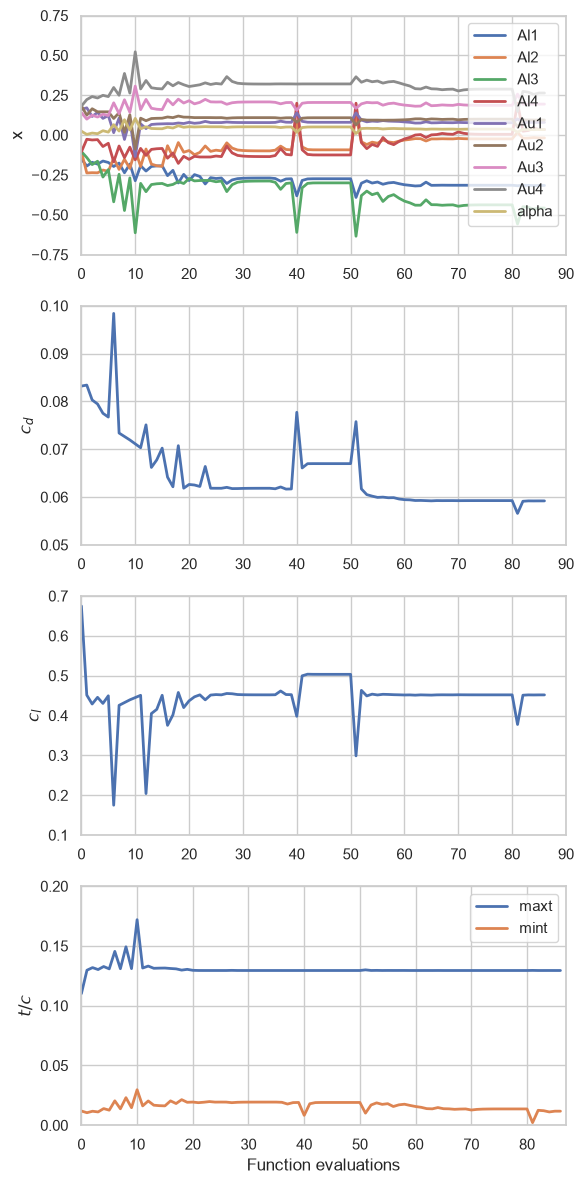

<Figure size 640x480 with 0 Axes>

In [24]:
plot_history("Lab3/airfoil")
plt.savefig("Lab3/history.png", dpi=300)

In [25]:
print("Tempo: %dm %ds" % divmod(elapsed, 60))

Tempo: 240m 44s


### 5. Desenhe 1) gráficos sobrepondo a geometria, 2) gráficos sobrepondo curvas de Cp ao longo da corda e 3) gráficos sobrepondo curvas de Mach ao longo da corda dos aerofólios da Tab. 2 na condição de projeto transônica. O script da pasta 02_single_run pode ser útil para isso.

In [26]:
Cp_NACA = results_NACA['distrib']['Cp']
Mach_NACA = results_NACA['distrib']['Mach']
xx_NACA = results_NACA['distrib']['xx']
Cp = results['distrib']['Cp']
Mach = results['distrib']['Mach']
xx = results['distrib']['xx']
x_space = np.linspace(0, 1, 81)

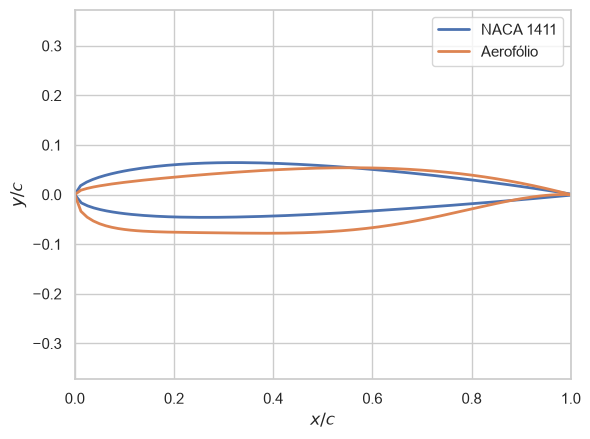

In [27]:
plt.figure()
am.nacafoil("1411", x_space, plot=True)
am.cstfoil(Au, Al, x_space, plot=True)
plt.xlabel(r"$x/c$")
plt.ylabel(r"$y/c$")
plt.legend(["NACA 1411", "Aerofólio"])
plt.axis("equal")
plt.xlim(0, 1)
plt.savefig("Lab3/aerofolio.png", dpi=300)

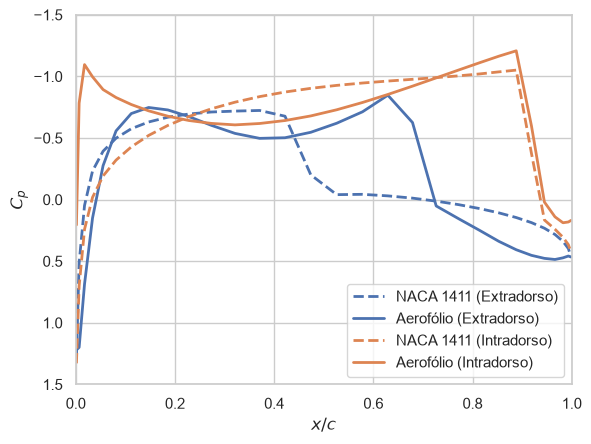

In [28]:
plt.figure()
sns.lineplot(x=xx_NACA[:len(xx_NACA)//2], y=Cp_NACA[:len(Cp_NACA)//2], label="NACA 1411 (Extradorso)", color="C0", linestyle="--")
sns.lineplot(x=xx[:len(xx)//2], y=Cp[:len(Cp)//2], label="Aerofólio (Extradorso)", color="C0")
sns.lineplot(x=xx_NACA[len(xx_NACA)//2:], y=Cp_NACA[len(Cp_NACA)//2:], label="NACA 1411 (Intradorso)", color="C1", linestyle="--")
sns.lineplot(x=xx[len(xx)//2:], y=Cp[len(Cp)//2:], label="Aerofólio (Intradorso)", color="C1")
plt.xlabel(r"$x/c$")
plt.ylabel(r"$C_p$")
plt.gca().invert_yaxis()
plt.legend()
plt.savefig("Lab3/Cp.png", dpi=300)

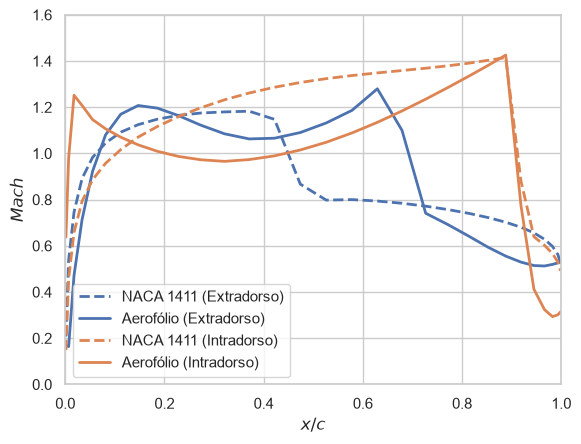

In [29]:
plt.figure()
sns.lineplot(x=xx_NACA[:len(xx_NACA)//2], y=Mach_NACA[:len(Mach_NACA)//2], label="NACA 1411 (Extradorso)", color="C0", linestyle="--")
sns.lineplot(x=xx[:len(xx)//2], y=Mach[:len(Mach)//2], label="Aerofólio (Extradorso)", color="C0")
sns.lineplot(x=xx_NACA[len(xx_NACA)//2:], y=Mach_NACA[len(Mach_NACA)//2:], label="NACA 1411 (Intradorso)", color="C1", linestyle="--")
sns.lineplot(x=xx[len(xx)//2:], y=Mach[len(Mach)//2:], label="Aerofólio (Intradorso)", color="C1")
plt.xlabel(r"$x/c$")
plt.ylabel(r"$Mach$")
plt.legend(loc="lower left")
plt.savefig("Lab3/Mach.png", dpi=300)

### 6. Use os gráficos gerados para explicar a abordagem aplicada pelo otimizador para chegar na configuração ótima.

Explicar

### 7. Adapte o script 02_single_run.py para gerar uma polar de arrasto para o perfil otimizado na condição transônica. Para isso, você precisará simular o perfil para uma sequência de ângulos de ataque e depois plotar os valores de cl e cd. Sugiro usar um intervalo de -2/+2 graus em relação ao ângulo de ataque do ponto ótimo. Lembre-se de destacar o ponto de projeto (cl da otimização) na polar. Sobreponha no mesmo gráfico uma curva correspondente ao aerofólio transônico RAE2822 (os dados desse aerofólio estão no arquivo single_run.py). Discuta se a polar do aerofólio otimizado tem alguma peculiaridade e se isso é bom ou ruim para o projeto de uma aeronave.

In [30]:
Au_RAE2822 = [0.12569744, 0.14564925, 0.1520378,  0.21346977, 0.17867926, 0.20872853]
Al_RAE2822 = [-0.13334359, -0.11827498, -0.22179445, -0.12644608, -0.08233977,  0.05193736]
alpha_graus = np.rad2deg(alpha)
alpha_graus_space = np.linspace(alpha_graus-2, alpha_graus+2, 9)

cl_space = []
cd_space = []
cl_space_RAE = []
cd_space_RAE = []

In [31]:
if len(cl_space) == 0:
    with working_directory("Lab3/varredura"):
        for alpha_graus in alpha_graus_space:
            results_varredura = rodar_euler(Al, Au, np.deg2rad(alpha_graus), Mach_cruise)
            cl_space.append(results_varredura['CL'])
            cd_space.append(results_varredura['CD'])
            print(f"alpha = {alpha_graus:.2f}°: cl = {results_varredura['CL']:.4f}, cd = {results_varredura['CD']:.4f}")

            results_RAE_varredura = rodar_euler(Al_RAE2822, Au_RAE2822, np.deg2rad(alpha_graus), Mach_cruise)
            cl_space_RAE.append(results_RAE_varredura['CL'])
            cd_space_RAE.append(results_RAE_varredura['CD'])
            print(f"alpha = {alpha_graus:.2f}°: cl_RAE = {results_RAE_varredura['CL']:.4f}, cd_RAE = {results_RAE_varredura['CD']:.4f}")

2D Grid generator
Written by:
Ney Rafael Secco
ney@ita.br
Jan 2016
Rev: Aug 2022

Growth ratio:  1.1404314716680044
Results
max thickness= 0.12946001426872025
max thickness x/c= 0.4477357683661733
max camber= -0.022725244402279764
max camber x/c= 0.09549150281252627
CL= -0.000940067232
CD= 0.0721441557
CM= -0.103763588
alpha = 0.01°: cl = -0.0009, cd = 0.0721
2D Grid generator
Written by:
Ney Rafael Secco
ney@ita.br
Jan 2016
Rev: Aug 2022

Growth ratio:  1.1404314716680044
Results
max thickness= 0.12088674399492144
max thickness x/c= 0.3960441545911204
max camber= 0.012683864983431124
max camber x/c= 0.7499999999999999
CL= 0.489371245
CD= 0.0733706128
CM= -0.261566142
alpha = 0.01°: cl_RAE = 0.4894, cd_RAE = 0.0734
2D Grid generator
Written by:
Ney Rafael Secco
ney@ita.br
Jan 2016
Rev: Aug 2022

Growth ratio:  1.1404314716680044
Results
max thickness= 0.12946001426872025
max thickness x/c= 0.4477357683661733
max camber= -0.022725244402279764
max camber x/c= 0.09549150281252627
CL= 0.08

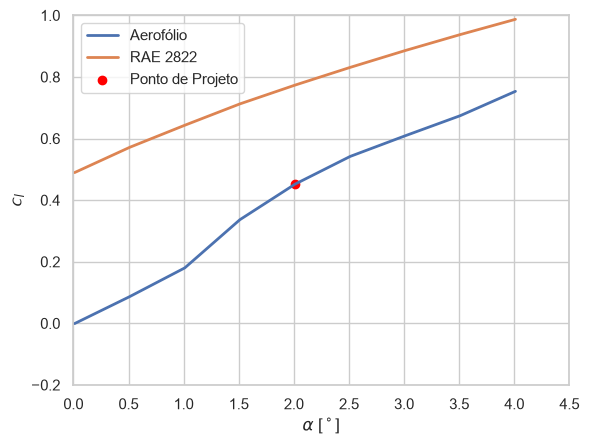

In [32]:
plt.figure()
plt.plot(alpha_graus_space, cl_space, label="Aerofólio")
plt.plot(alpha_graus_space, cl_space_RAE, label="RAE 2822")
plt.xlabel(r"$\alpha$ [$^\circ$]")
plt.ylabel(r"$c_l$")
plt.scatter(alpha_graus_space[len(alpha_graus_space)//2], cl_space[len(alpha_graus_space)//2], color='red', label="Ponto de Projeto")
plt.legend()
plt.savefig("Lab3/varredura_cl.png", dpi=300)

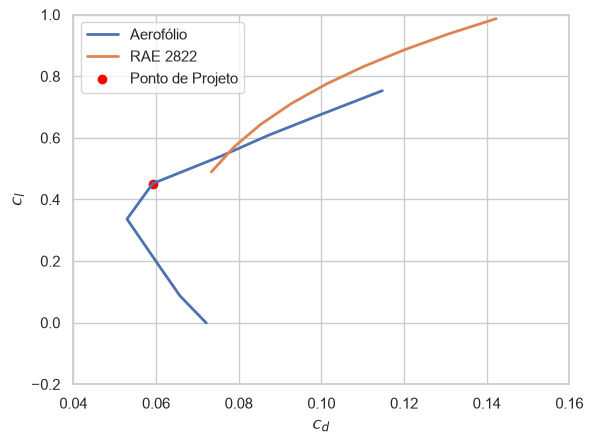

In [33]:
plt.figure()
plt.plot(cd_space, cl_space, label="Aerofólio")
plt.plot(cd_space_RAE, cl_space_RAE, label="RAE 2822")
plt.xlabel(r"$c_d$")
plt.ylabel(r"$c_l$")
plt.scatter(cd_space[len(cd_space)//2], cl_space[len(cl_space)//2], color='red', label="Ponto de Projeto")
plt.legend()
plt.savefig("Lab3/varredura_polar.png", dpi=300)

### 8. Exporte os aerofólios iniciais e finais da otimização para o formato Xfoil e gere curvas cl × α, cl × cd e cm × α para os dois aerofólios em regime subsônico (pode desconsiderar o número de Mach para essa análise). Utilize a condição de decolagem da aeronave para determinar o número de Reynolds para essa simulação (lembre de indicar o número de Reynolds no relatório). Sobreponha as curvas dos dois aerofólios em cada plot e discuta as vantagens e desvantagens dos perfis no regime analisado.

In [34]:
alpha_graus_min = -1
alpha_graus_max = 20
alpha_graus_step = 0.1
polar_inicial_decolagem = rodar_xfoil_polar("Lab3/NACA", Re_decolagem, Mach_decolagem, alpha_graus_min, alpha_graus_max, alpha_graus_step, NACA="1411")
polar_final_decolagem = rodar_xfoil_polar("Lab3/airfoil", Re_decolagem, Mach_decolagem, alpha_graus_min, alpha_graus_max, alpha_graus_step)

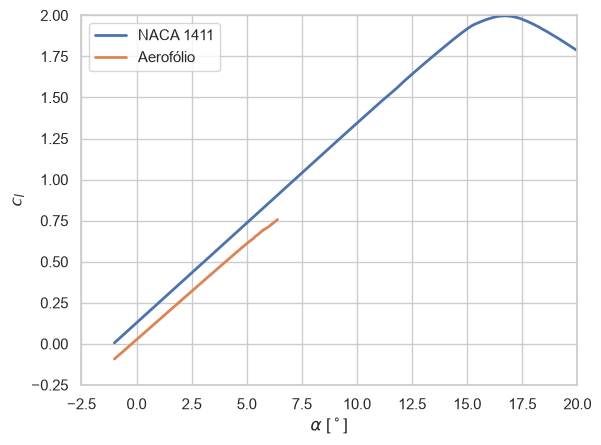

In [35]:
# cl x alpha
plt.figure()
plt.plot(polar_inicial_decolagem["alpha"], polar_inicial_decolagem["CL"], label="NACA 1411")
plt.plot(polar_final_decolagem["alpha"], polar_final_decolagem["CL"], label="Aerofólio")
plt.xlabel(r"$\alpha$ [$^\circ$]")
plt.ylabel(r"$c_l$")
plt.legend()
plt.savefig("Lab3/polar_cl_decolagem.png", dpi=300)

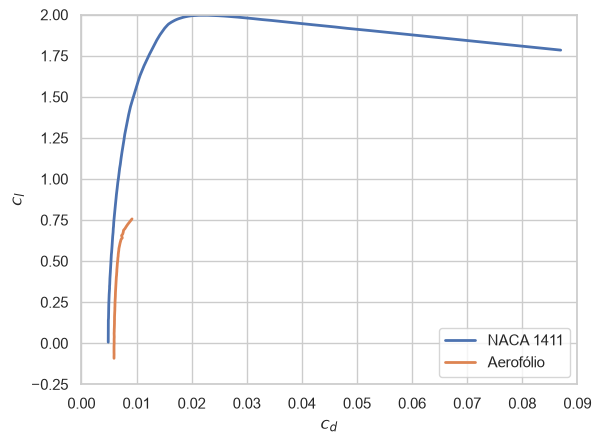

In [36]:
# cl x cd
plt.figure()
plt.plot(polar_inicial_decolagem["CD"], polar_inicial_decolagem["CL"], label="NACA 1411")
plt.plot(polar_final_decolagem["CD"], polar_final_decolagem["CL"], label="Aerofólio")
plt.xlabel(r"$c_d$")
plt.ylabel(r"$c_l$")
plt.legend()
plt.savefig("Lab3/polar_cd_decolagem.png", dpi=300)

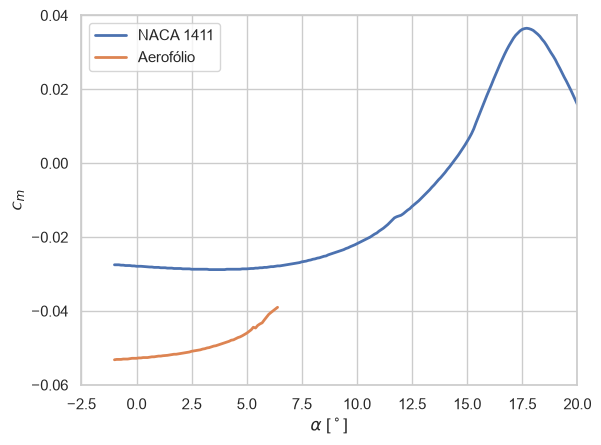

In [37]:
# cm x alpha
plt.figure()
plt.plot(polar_inicial_decolagem["alpha"], polar_inicial_decolagem["CM"], label="NACA 1411")
plt.plot(polar_final_decolagem["alpha"], polar_final_decolagem["CM"], label="Aerofólio")
plt.xlabel(r"$\alpha$ [$^\circ$]")
plt.ylabel(r"$c_m$")
plt.legend()
plt.savefig("Lab3/polar_cm_decolagem.png", dpi=300)

### 9. Verifiquem a possibilidade de alterar a definição da otimização para obter um aerofólio de melhor característica no regime subsônico.

Mach subsônico provavelmente levaria a um aerofólio parecido com um aerofólio subsônico ao invés de um supercrítico.

### 10. Quem estiver com o Paraview (https://www.paraview.org/download/) instalado no computador pode observar a solução no domínio carregando o arquivo paraview_state_windows.py com a opção “Load State”. Esse arquivo sempre carregará o arquivo solution.vtk da pasta 02_single_run.